# Customer Segmentation RFM Analysis and K-Means Clustering

## Background 
Businesses generate large volumes of customer transaction data in their day to day operations to keep track of sales and revenue across a given period of time. Nonetheless, raw transactional records alone do not provide actionable insights, that can support informed business decision-making. This limits the ability of organizations to understand customers purchasing patterns, identify high value customers and develop and effective customer retention strategy. 

Customer segmentation enables businesses to group customers based on similar purchaing behavious, helping organizations better understand customer value, improve personalized marketing efforts, enhance customer engagement and optimize overall business performance.

## Problem statement
Many businesses lack a structured understanding of customer purchasing behaviour, making it difficult to identify high-value customers, detect customers at risk of churn, develop personalized marketing strategies, and improve customer retention. As a result, businesses may experience reduced customer engagement, increased customer loss, and declining revenue performance.

To address this challenge, this project applies RFM Analysis (Recency, Frequency, Monetary) and K-Means clustering techniques to analyze customer purchasing behaviour and segment customers into distinct groups. The segmentation enables the generation of actionable business insights that can support targeted marketing, customer retention, and data-driven decision-making.

## Data Understanding
The dataset used in this project is the Online Retail Dataset from kaggle where each row represents a purchased product within a transaction.
The dataset contains online retail records including:
- Invoice numbers
-  Product descriptions
- Quantities purchased
- Purchase dates 
- Unit Prices
- Customer OSs
- Country information

### Transaction Structure
- One customer can have multiple transactions over time
- One invoice number represents a single transaction
- A single transaction may contain multiple purchased products
- Customers purchasing multiple products within the same transaction share the same InvoiceNo and CustomerID

## Data Cleaning and Inspection 

In [353]:
import pandas as pd
import numpy as np

In [354]:
df = pd.read_csv("./Data/Online Retail Dataset.csv", encoding="latin-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Missing values 
- Removed rows with missing customer IDs
- Removed rows with missing descriptions 

In [356]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [357]:
df["Description"].value_counts().head(10)

WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: Description, dtype: int64

In [358]:
# percentage of missing values in the description column 
1454/541909 * 100 

0.2683107311375157

In [359]:
df = df.dropna(subset=['Description'])

In [360]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

In [361]:
# Percentage of missing values in the customers Id column 
133626 /541909 * 100 

24.658383603151083

In [362]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [363]:
df = df.dropna(subset=['CustomerID'])

In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [365]:
df.shape

(406829, 8)

#### Returned Transactions
- Removed transactions wiith negative quantities to focus on completed purchases

In [366]:
# Checking for negative quantity (returned items or cancelled transactions)
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [367]:
# Filtered the returned items to focus on customer purchasing behaviour 
# Retained quatity that is greater than 0
df = df[df["Quantity"] > 0]

In [368]:
# confirmation of filtering 
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Transactions with negative quantities were identified as returns and excluded from the analysis to ensure that customer value metrics reflect actual purchasing behavior.

#### Duplicate Records
- Removed  duplicate rows to improve data quality

In [369]:
# Checking for duplicates 
df.duplicated().sum()

5192

In [370]:
# Dropped duplicates based on Key columns in the dataset
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'CustomerID', 'Quantity', 'InvoiceDate'])

In [371]:
df.duplicated().sum()

0

Duplicate transaction rows were identified and removed to prevent inflation of customer-level metrics such as frequency and monetary value in the RFM analysis.

#### Invalid Prices 
- Investigated zero-priced items
- Removed or retained depending on business logic

In [372]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12/5/2010 14:02,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,12/16/2010 14:36,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,12/21/2010 13:45,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,1/6/2011 16:41,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,1/6/2011 16:41,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,1/13/2011 15:10,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2/10/2011 13:08,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,3/23/2011 10:25,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,3/30/2011 12:45,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,4/4/2011 14:42,0.0,14410.0,United Kingdom


In [373]:
df[df['UnitPrice'] == 0].head()
df['UnitPrice'].describe()

count    392708.000000
mean          3.105736
std          21.518804
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

Summary:
- min= 0.00 some items are free or invalid
- median = 1.95 most products are cheap
- 75% = 3.75 majority are low priced products 
- max = 8142.75 This is an extreme outlier 

In [374]:
# Filtered items with a unit price of zero 
df = df[df["UnitPrice"] > 0]

In [375]:
# confirmation of filtering 
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [376]:
#df.to_csv("cleaned_transactions.csv", index=False)

## Feature Engineering 

In [377]:
df_cleaned = pd.read_csv("./Data/cleaned_transactions.csv")
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [378]:
df_cleaned.dtypes

InvoiceNo        int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
TotalPrice     float64
dtype: object

In [379]:
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

In [380]:
snapshot_date = df_cleaned['InvoiceDate'].max()

recency = snapshot_date - df_cleaned.groupby('CustomerID')['InvoiceDate'].max()

In [381]:
df_cleaned.dtypes

InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalPrice            float64
dtype: object

In [382]:
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [383]:
# Creation of the Total Price column 
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

In [384]:
#df_cleaned.to_csv("cleaned_transactions.csv", index=False)

## RFM Dataset Creation

### RFM Metric Definitions
The project applies RFM analysis using the following metrics:

Recency – Number of days since the customer’s last purchase
Frequency – Number of unique invoices/transactions made by the customer
Monetary – Total amount spent by the customer across all transactions

In [385]:
rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [386]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [387]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Float64Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


## Customer Segmentation Using K-Means
### Clustering Technique
Applied K-Means clustering to group customers based on purchasing behavior.

In [388]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline


In [389]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('KMeans', KMeans(n_clusters=4, random_state=42))
])
features = rfm[['Recency', 'Frequency','Monetary']]

rfm['Cluster'] = pipe.fit_predict(features)

c:\Users\hp\anaconda3\envs\learn-env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


A pipeline was implemented to standardize customer features and apply K-Means clustering, ensuring a consistent and reproducible segmentation workflow.

### Cluster Interpretation

In [390]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,42.878193,3.663392,1351.615060
1,247.469426,1.553151,478.625711
2,6.384615,82.538462,127169.376154
3,14.384615,22.206731,12445.836490


Each row represents the average customer behavior in that cluster. The metrics of measure are as follows:
- Recency - Lower = more recent(good for business, customer is still engaged)
- Frequency - Higher = buys more often 
- Monetary - Higher = spends more(Bulk buying for business or big spenders)

### Cluster 2 → VIP / High-Value Customers
Recency: 6 days (very recent)
Frequency: 82 (extremely frequent)
Monetary: 127,169 (very high spend)

Your best customers
Highly engaged + high revenue

Business meaning:
Core revenue drivers
Likely loyal or business buyers

Action:
Retain at all costs
Offer loyalty rewards / exclusives

### Cluster 3 → Loyal Customers
Recency: 14 days
Frequency: 22
Monetary: 12,445

Strong, consistent customers
Not as extreme as VIPs but still valuable

Business meaning:
Reliable revenue base

Action:
Upsell / cross-sell
Move them toward VIP segment

### Cluster 0 → Potential Loyal / Mid-Value
Recency: 42 days
Frequency: 3.6
Monetary: 1,351

Occasional buyers
Moderate spend

Business meaning:
Growth opportunity segment

Action:
Targeted marketing
Engagement campaigns

### Cluster 1 → At-Risk / Low-Value Customers
Recency: 247 days (haven’t purchased in a long time)
Frequency: 1.5
Monetary: 478

Almost inactive
Low engagement
Business meaning:

High churn risk

Action:
Reactivation campaigns
Discounts or reminders

Customer segmentation revealed four distinct behavioral groups ranging from low-engagement, at-risk customers to high-value, highly active customers. The segmentation enables targeted marketing strategies tailored to each group’s engagement and value profile.

#### Segment Labeling
Clusters were interpreted and mapped into business-friendly customer segments.

In [391]:
# Segmenting the customers according to clusters
rfm['Segment'] = rfm['Cluster'].map({
    2: 'VIP',
    3: 'Loyal',
    0: 'Potential',
    1: 'At Risk'
})
rfm

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,325,1,77183.60,3,Loyal
12347.0,1,7,4310.00,0,Potential
12348.0,74,4,1797.24,0,Potential
12349.0,18,1,1757.55,0,Potential
12350.0,309,1,334.40,1,At Risk
...,...,...,...,...,...
18280.0,277,1,180.60,1,At Risk
18281.0,180,1,80.82,1,At Risk
18282.0,7,2,178.05,0,Potential


## Visualizations.

In [392]:
import matplotlib.pyplot as plt
import seaborn as sns

### Customer Segmentation: Monetary vs Frequency

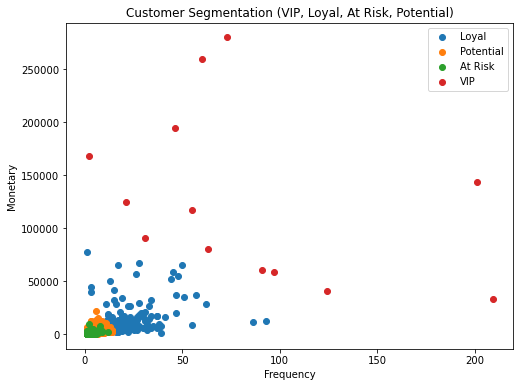

In [393]:
plt.figure(figsize=(8,6))

for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Frequency'], subset['Monetary'], label=segment)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segmentation (VIP, Loyal, At Risk, Potential)')
plt.legend()
plt.show()

This is a visualization showing customer segmentation of Monetary vs Frequency. From the scatter plot it is evident that VIP customers are the core revenue spenders and should be retained at all costs,  moreover they have the most number of frequency days showing that they are still engaged with the products or might be bulk buyers.

In another dimension it shows the at risk customers who have low monetary and frequency values indicating low engagement and the need for reactivation campaigns.

#### Customer Segments by Frequency

In [394]:
color_map = {
    'VIP': 'green',
    'Loyal': 'blue',
    'Potential': 'orange',
    'At Risk': 'red'
}

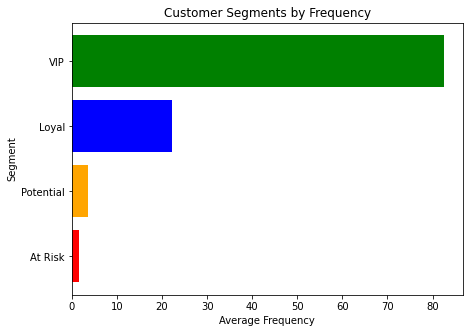

In [395]:
freq = rfm.groupby('Segment')['Frequency'].mean().sort_values()

plt.figure(figsize=(7,5))
plt.barh(freq.index, freq.values, color=[color_map[s] for s in freq.index])

plt.title('Customer Segments by Frequency')
plt.xlabel('Average Frequency')
plt.ylabel('Segment')

plt.show()

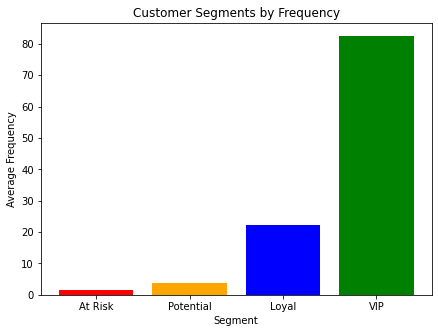

In [396]:
freq = rfm.groupby('Segment')['Frequency'].mean().sort_values()

plt.figure(figsize=(7,5))
plt.bar(freq.index, freq.values, color=[color_map[s] for s in freq.index])

plt.title('Customer Segments by Frequency')
plt.xlabel('Segment')
plt.ylabel('Average Frequency')

plt.show()

This visualization shows customer segments by Frequency. The high frequency is tied to VIP customers indicating high customer engagement in the business on the other hand At Risk customers have low average frequency indicating low engagement or inactive customer base that is in urgent need for intervention

#### Customer Segments by Recency 

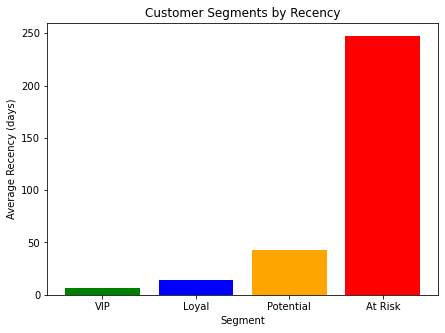

In [397]:
rec = rfm.groupby('Segment')['Recency'].mean().sort_values()

plt.figure(figsize=(7,5))
plt.bar(rec.index, rec.values, color=[color_map[s] for s in rec.index])

plt.title('Customer Segments by Recency')
plt.xlabel('Segment')
plt.ylabel('Average Recency (days)')

plt.show()

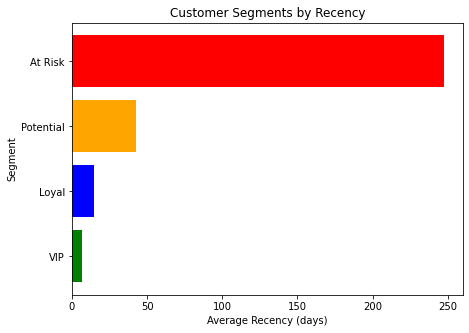

In [398]:
rec = rfm.groupby('Segment')['Recency'].mean().sort_values()

plt.figure(figsize=(7,5))
plt.barh(rec.index, rec.values, color=[color_map[s] for s in rec.index])

plt.title('Customer Segments by Recency')
plt.xlabel('Average Recency (days)')
plt.ylabel('Segment')

plt.show()

The visualization above shows At Risk customers have a very high average recency which is an indicator of low egagement since it's been too long since they made a purchase. This calls for reactivation campaigns, discounts and reminders to keep the customers engaged.

On the other hand VIP customers have a low average recency, showing high engagement with the products.

### Customer segments by Monetary Spending

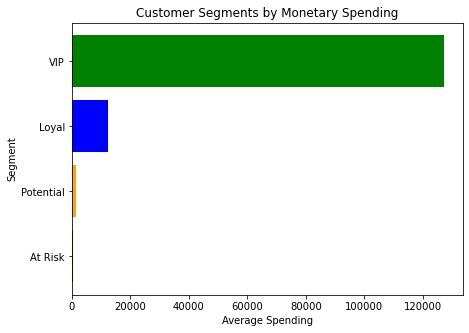

In [399]:
# Customer segments by Monetary spending 
mone = rfm.groupby('Segment')['Monetary'].mean().sort_values()

plt.figure(figsize=(7,5))
plt.barh(mone.index, mone.values, color=[color_map[s] for s in mone.index])

plt.title('Customer Segments by Monetary Spending')
plt.xlabel('Average Spending')
plt.ylabel('Segment')

plt.show()

In the above visualization it is evident that VIP customers have a very high average spending compared to other customer segments. This indicates that the business should ensure to retain these customers at all costs giving exclusives and loyalty points for their engagement.For the at Risk customers who have zero average spending as a business we should focus on reactivation campaigns and reminders to attract spending.

#### Spending Tier Classification
Customers were categorized into spending tiers based on monetary value.

In [400]:
# Doing further segmentation into spending clusters across segments
rfm['Spending'] = pd.qcut(
    rfm['Monetary'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment,Spending
CustomerID,,,,,,
12346.0,325,1,77183.60,3,Loyal,High
12347.0,1,7,4310.00,0,Potential,High
12348.0,74,4,1797.24,0,Potential,High
12349.0,18,1,1757.55,0,Potential,High
12350.0,309,1,334.40,1,At Risk,Mid-Low


In [401]:
rfm.groupby(['Cluster', 'Spending']).size()

Cluster  Spending
0        Low         571
         Mid-Low     723
         Mid-High    938
         High        822
1        Low         514
         Mid-Low     361
         Mid-High    145
         High         43
2        Low           0
         Mid-Low       0
         Mid-High      0
         High         13
3        Low           0
         Mid-Low       0
         Mid-High      1
         High        207
dtype: int64

In [402]:
# confirming we have 4 equal clusters fro monetary spending 
rfm['Spending'].value_counts()

High        1085
Low         1085
Mid-High    1084
Mid-Low     1084
Name: Spending, dtype: int64

In [403]:
# creation of a table that shows spending vs segment
pd.crosstab(rfm['Segment'], rfm['Spending'])

Spending,Low,Mid-Low,Mid-High,High
Segment,,,,
At Risk,514,361,145,43
Loyal,0,0,1,207
Potential,571,723,938,822
VIP,0,0,0,13


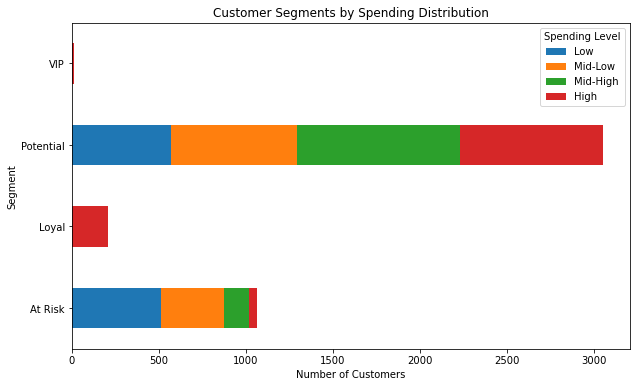

In [404]:
# Create crosstab
ct = pd.crosstab(rfm['Segment'], rfm['Spending'])

# Plot
ct.plot(kind='barh', stacked=True, figsize=(10,6))

plt.title('Customer Segments by Spending Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')

plt.legend(title='Spending Level')
plt.show()

The visualization above shows that high/big spenders are concentrated across two clusters that is Potential and Loyal customers reinforcing the idea that those two segments are the core drivers of revenue in the business. VIP has a small number of high spenders only showing that they might be bulky purchasers or individual business entities.

In [405]:
# Saving the final datasets
SAVE = False

if SAVE:
    df_cleaned.to_csv("cleaned_transactions.csv", index=False)
    rfm.to_csv("customer_rfm.csv", index=False)
    rfm.to_csv("rfm_segmenated.csv", index=False)
    

## Key Findings & Insights
### VIP Customers
- Highest spending customers
- Most frequent purchasers
- Most recently active
- Business Implication

These customers contribute significantly to revenue and should be prioritized for retention.

### Loyal Customers
- Strong purchasing consistency
- High engagement levels
- Business Implication

Potential for upselling and cross-selling opportunities.

### Potential Customers
- Moderate activity and spending
- Mixed customer behavior
- Business Implication

Can be nurtured into loyal customers through targeted campaigns.

### At-Risk Customers
- Low engagement
- Long inactivity periods
- Low spending
- Business Implication

Require reactivation strategies to reduce churn risk.

## Business Recommendations
### VIP Customers
- Introduce loyalty rewards
- Offer exclusive promotions
- Provide premium customer experiences
### Loyal Customers
- Implement upselling strategies
- Promote complementary products
- Encourage repeat purchases
### Potential Customers
- Use personalized marketing campaigns
- Offer discounts and incentives
- Increase engagement through targeted communication
### At-Risk Customers
- Launch reactivation campaigns
- Send reminders and retention offers
- Investigate causes of disengagement